In [3]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate

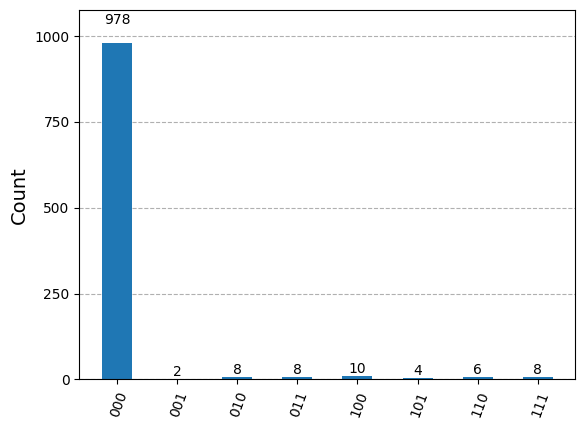

In [4]:
# Grover's algorithm
# Given a function f : {0,1}^n -> {0,1} such that for some input vector w,
# f(w) = 1 and for all x != w, f(x) = 0.
# The problem is to find w.

# Here we work with 3 qubits

# First we need a definition of f.

# Let's say f(0,0,0) = 1
# Try changing this to represent different search targets (you will need to change the definition of U, below)

# Then we need to define a unitary operator U on 3 qubits, such that
# U|x> = -|x> if f(x) = 1
# U|x> =  |x> if f(x) = 0

U = Operator([
   [-1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]
])

# Now construct the Grover diffusion operator

G_matrix = list(map(lambda x: list(map(lambda y: y/4.0,x)),[
    [-3,1, 1, 1, 1, 1, 1, 1],
    [1,-3, 1, 1, 1, 1, 1, 1],
    [1, 1,-3, 1, 1, 1, 1, 1],
    [1, 1, 1,-3, 1, 1, 1, 1],
    [1, 1, 1, 1,-3, 1, 1, 1],
    [1, 1, 1, 1, 1,-3, 1, 1],
    [1, 1, 1, 1, 1, 1,-3, 1],
    [1, 1, 1, 1, 1, 1, 1,-3]
]))

G = Operator(G_matrix)

# Build a circuit with the correct number of iterations hard-coded, in this case 2

grover = QuantumCircuit(3)

# To get the initial state, apply H to every qubit

grover.h(0)
grover.h(1)
grover.h(2)

# Repeatedly apply U then G

grover.append(U,[0,1,2])
grover.append(G,[0,1,2])
grover.append(U,[0,1,2])
grover.append(G,[0,1,2])

# What if we do too many iterations?

#grover.append(U,[0,1,2])
#grover.append(G,[0,1,2])

# Measure all the qubits - to do that, we don't need to introduce classical bits

grover.measure_all()

# Simulate and plot results

backend = BasicSimulator()
compiled = transpile(grover, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
plot_histogram(counts)

Too few (1 iter): {'011': 37, '000': 826, '010': 25, '001': 38, '110': 20, '111': 37, '101': 22, '100': 19}


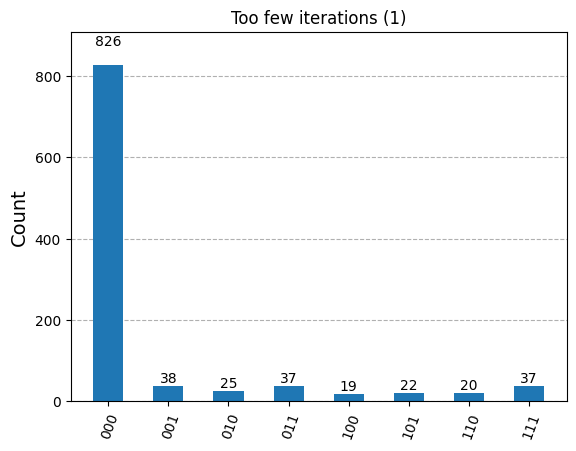

In [9]:
grover_few = QuantumCircuit(3)
grover_few.h([0, 1, 2])

grover_few.append(U, [0, 1, 2])   # only 1 iteration
grover_few.append(G, [0, 1, 2])

grover_few.measure_all()

compiled = transpile(grover_few, backend)
counts_few = backend.run(compiled, shots=1024).result().get_counts(compiled)
print("Too few (1 iter):", counts_few)
plot_histogram(counts_few, title="Too few iterations (1)")

Too many (4 iters): {'100': 142, '001': 137, '101': 150, '110': 138, '010': 155, '111': 142, '011': 149, '000': 11}


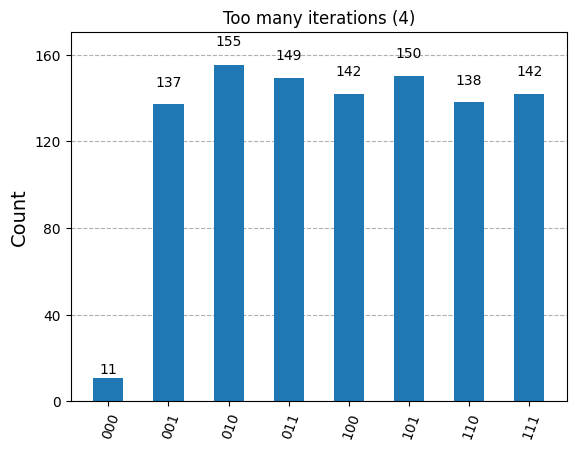

In [10]:
grover_many = QuantumCircuit(3)
grover_many.h([0, 1, 2])

for _ in range(4):                 # 4 iterations — too many, algorithm overshoots
    grover_many.append(U, [0, 1, 2])
    grover_many.append(G, [0, 1, 2])

grover_many.measure_all()

compiled = transpile(grover_many, backend)
counts_many = backend.run(compiled, shots=1024).result().get_counts(compiled)
print("Too many (4 iters):", counts_many)
plot_histogram(counts_many, title="Too many iterations (4)")

Target |101>: {'101': 965, '111': 9, '010': 10, '001': 10, '011': 8, '000': 11, '100': 5, '110': 6}


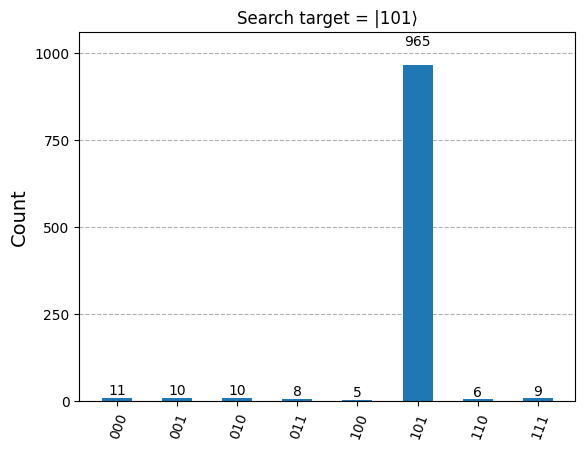

In [7]:
# To search for |101>, put the -1 at row/column index 5
U_101 = Operator([
    [ 1, 0, 0, 0, 0, 0, 0, 0],
    [ 0, 1, 0, 0, 0, 0, 0, 0],
    [ 0, 0, 1, 0, 0, 0, 0, 0],
    [ 0, 0, 0, 1, 0, 0, 0, 0],
    [ 0, 0, 0, 0, 1, 0, 0, 0],
    [ 0, 0, 0, 0, 0,-1, 0, 0],   # <-- marks |101>
    [ 0, 0, 0, 0, 0, 0, 1, 0],
    [ 0, 0, 0, 0, 0, 0, 0, 1]
])

grover_101 = QuantumCircuit(3)
grover_101.h([0, 1, 2])
grover_101.append(U_101, [0, 1, 2])
grover_101.append(G,     [0, 1, 2])
grover_101.append(U_101, [0, 1, 2])
grover_101.append(G,     [0, 1, 2])
grover_101.measure_all()

compiled = transpile(grover_101, backend)
counts_101 = backend.run(compiled, shots=1024).result().get_counts(compiled)
print("Target |101>:", counts_101)
plot_histogram(counts_101, title="Search target = |101⟩")